# Data Exploration - parrot species Kaggle dataset

https://www.kaggle.com/datasets/zuhaibbutt/parrots-species-dataset

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

RAW_DATA_DIR = Path("../data/raw/parrot_images")

RAW_DATA_DIR.exists()

True

In [2]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

class_dirs = sorted([path for path in RAW_DATA_DIR.iterdir() if path.is_dir()])

class_summary = []

for class_dir in class_dirs:
    image_files = [
        file
        for file in class_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    class_summary.append({
        "class_name": class_dir.name,
        "image_count": len(image_files)
    })

class_summary_df = pd.DataFrame(class_summary)

class_summary_df

,class_name,image_count
0,Andean_parakeet,5
1,Antipodes_parakeet,5
2,Austral_parakeet,5
3,Australian_ringneck,5
4,Aztec_parakeet,5
...,...,...
212,Yellow-faced_parrotlet,5
213,Yellow-fronted_parrot,3
214,Yellow-headed_amazon,5
215,Yellow-naped_amazon,3


In [3]:
num_classes = len(class_summary_df)
total_images = class_summary_df["image_count"].sum()

print(f"Number of classes: {num_classes}")
print(f"Total images: {total_images}")
print(f"Average images per class: {total_images / num_classes:.2f}")

Number of classes: 217
Total images: 1000
Average images per class: 4.61


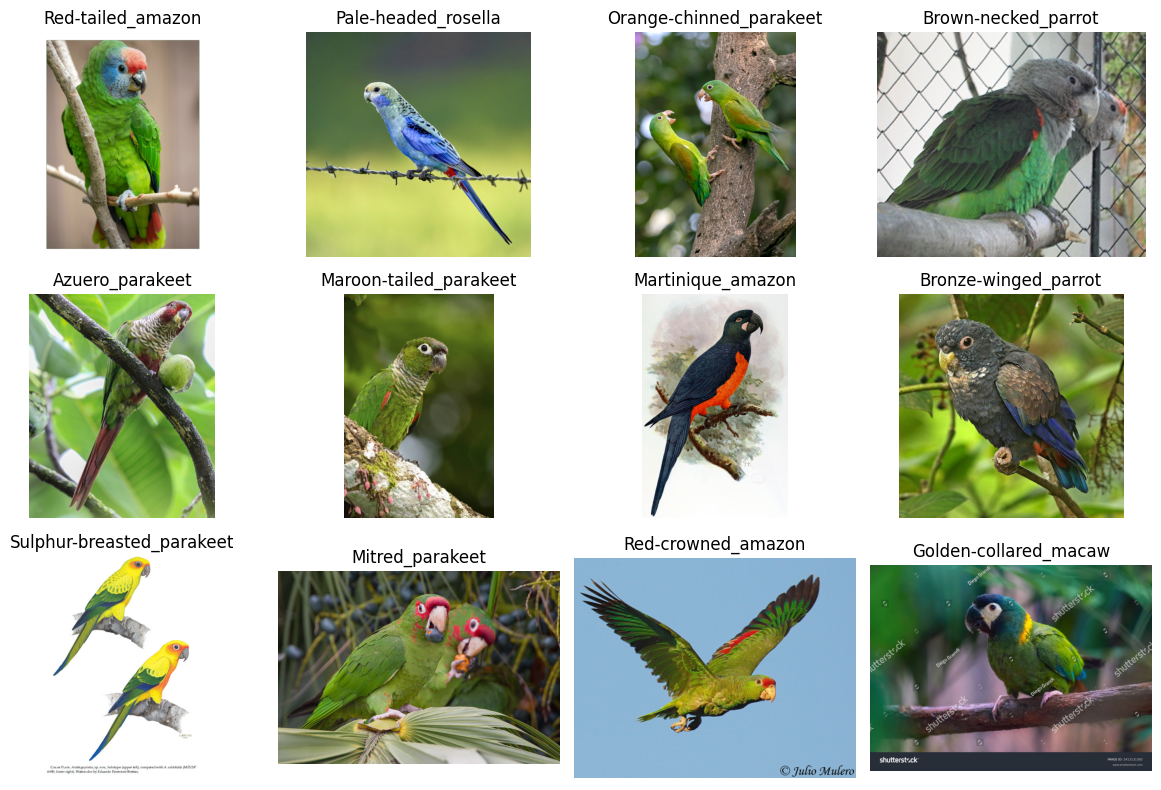

In [5]:
import random

num_samples = 12

all_image_paths = []

for class_dir in class_dirs:
    image_paths = [
        file
        for file in class_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]
    all_image_paths.extend(image_paths)

sample_paths = random.sample(all_image_paths, min(num_samples, len(all_image_paths)))

plt.figure(figsize=(12, 8))

for index, image_path in enumerate(sample_paths):
    image = Image.open(image_path)

    plt.subplot(3, 4, index + 1)
    plt.imshow(image)
    plt.title(image_path.parent.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
image_metadata = []

for class_dir in class_dirs:
    image_paths = [
        file
        for file in class_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    for image_path in image_paths:
        try:
            with Image.open(image_path) as image:
                image_metadata.append({
                    "path": str(image_path),
                    "class_name": class_dir.name,
                    "width": image.width,
                    "height": image.height,
                    "mode": image.mode,
                    "format": image.format,
                    "is_readable": True,
                })
        except Exception as error:
            image_metadata.append({
                "path": str(image_path),
                "class_name": class_dir.name,
                "width": None,
                "height": None,
                "mode": None,
                "format": None,
                "is_readable": False,
                "error": str(error),
            })

image_metadata_df = pd.DataFrame(image_metadata)

image_metadata_df.head()

,path,class_name,width,height,mode,format,is_readable
0,..\data\raw\parrot_images\Andean_parakeet\0000...,Andean_parakeet,652,412,RGB,JPEG,True
1,..\data\raw\parrot_images\Andean_parakeet\0000...,Andean_parakeet,652,412,RGB,JPEG,True
2,..\data\raw\parrot_images\Andean_parakeet\0000...,Andean_parakeet,466,700,RGB,JPEG,True
3,..\data\raw\parrot_images\Andean_parakeet\0000...,Andean_parakeet,973,816,P,PNG,True
4,..\data\raw\parrot_images\Andean_parakeet\0000...,Andean_parakeet,640,480,RGB,JPEG,True


In [7]:
image_metadata_df.shape

(1000, 7)

In [8]:
image_metadata_df["is_readable"].value_counts()

is_readable
True    1000
Name: count, dtype: int64

In [9]:
image_metadata_df["mode"].value_counts()

mode
RGB     940
P        38
RGBA     20
L         2
Name: count, dtype: int64

In [10]:
image_metadata_df[["width", "height"]].describe()

,width,height
count,1000.000000,1000.000000
mean,1170.939000,1065.969000
std,938.887174,827.295307
min,200.000000,203.000000
25%,600.000000,571.500000
50%,802.000000,768.000000
75%,1318.750000,1316.250000
max,7767.000000,7767.000000


## Dataset observations and how they affect preprocessing

From the initial dataset inspection, we found that all images are readable, but the dataset is not fully standardized.

The image color modes are mixed:
- Most images are RGB
- Some images are P mode
- Some images are RGBA
- A small number are grayscale

Because of this, the preprocessing pipeline should convert every image to RGB before training. This ensures that every image has three color channels, which is required for most pretrained computer vision models in PyTorch.

We also found that image sizes vary significantly. Some images are relatively small, while others are very large. Since neural networks require fixed-size tensor inputs, the preprocessing pipeline should resize all images to a consistent shape, most likely 224x224.

## How this connects to feature engineering

For this computer vision project, feature engineering will not involve manually creating columns like in a tabular ML project. Instead, feature engineering will mainly come from image transformations and augmentation.

The main feature engineering choices will include:
- resizing images to a consistent input size
- converting images to tensors
- normalizing pixel values
- applying data augmentation such as random flips, rotations, crops, and color changes

These transformations help the model learn more general visual patterns instead of memorizing the small number of images in the dataset.

Because the current dataset has very few images per class, augmentation and transfer learning will be especially important. We will use a pretrained computer vision model later so that the model starts with useful visual features learned from a much larger dataset.

In [11]:
class_summary_df.sort_values("image_count", ascending=True).head(20)

,class_name,image_count
13,Black-winged_parrot,1
112,Naretha_bluebonnet,1
80,Grey_parrot,1
74,Green-rumped_parrotlet,1
124,Pacific_parakeet,1
152,Red-spectacled_amazon,1
203,White-eyed_parakeet,1
205,White-winged_parakeet,2
185,Sun_parakeet,3
187,Tepui_parrotlet,3


In [12]:
class_summary_df["image_count"].describe()

count    217.000000
mean       4.608295
std        1.062198
min        1.000000
25%        5.000000
50%        5.000000
75%        5.000000
max        8.000000
Name: image_count, dtype: float64

## Class balance observation

The dataset is not heavily imbalanced because most classes have around 5 images.

However, the dataset is extremely small for a 217-class image classification problem. Some classes have only 1 image, and the maximum number of images in any class is only 8.

This means the main modeling challenge is not class imbalance, but data scarcity.

Because of this, we should not train a model from scratch. Instead, we should use transfer learning with a pretrained computer vision model and apply image augmentation during training.

This dataset will be useful for developing the full end-to-end ML pipeline, but model accuracy should be interpreted carefully until a larger dataset is used.

In [14]:
classes_less_than_5 = class_summary_df[class_summary_df["image_count"] < 5]

num_classes_less_than_5 = len(classes_less_than_5)

print(f"Number of classes with fewer than 5 images: {num_classes_less_than_5}")
print(f"Percentage of classes with fewer than 5 images: {num_classes_less_than_5 / len(class_summary_df) * 100:.2f}%")

classes_less_than_5.sort_values("image_count")

Number of classes with fewer than 5 images: 43
Percentage of classes with fewer than 5 images: 19.82%


,class_name,image_count
13,Black-winged_parrot,1
74,Green-rumped_parrotlet,1
80,Grey_parrot,1
112,Naretha_bluebonnet,1
124,Pacific_parakeet,1
152,Red-spectacled_amazon,1
203,White-eyed_parakeet,1
205,White-winged_parakeet,2
144,Red-faced_parrot,3
134,Puerto_Rican_amazon,3


## Low-sample class decision

We found that 43 classes have fewer than 5 images, which represents 19.82% of the total classes.

Because these classes have too few examples to support a reliable train/validation/test split, we will exclude them from the modeling dataset for now.

For this project version, we will only keep classes with at least 5 images.

This decision helps make the preprocessing pipeline more stable and reduces issues during dataset splitting. However, the dataset is still very small overall, so we will continue treating this as a prototype dataset for building the end-to-end ML pipeline rather than a final production-quality model dataset.

In [15]:
MIN_IMAGES_PER_CLASS = 5

eligible_classes_df = class_summary_df[
    class_summary_df["image_count"] >= MIN_IMAGES_PER_CLASS
].copy()

excluded_classes_df = class_summary_df[
    class_summary_df["image_count"] < MIN_IMAGES_PER_CLASS
].copy()

print(f"Eligible classes: {len(eligible_classes_df)}")
print(f"Excluded classes: {len(excluded_classes_df)}")
print(f"Images kept: {eligible_classes_df['image_count'].sum()}")
print(f"Images excluded: {excluded_classes_df['image_count'].sum()}")

eligible_classes_df.sort_values("class_name").head()

Eligible classes: 174
Excluded classes: 43
Images kept: 883
Images excluded: 117


,class_name,image_count
0,Andean_parakeet,5
1,Antipodes_parakeet,5
2,Austral_parakeet,5
3,Australian_ringneck,5
4,Aztec_parakeet,5


## Filtered modeling dataset

After applying the minimum image threshold, we kept only classes with at least 5 images.

This reduced the dataset from 217 classes to 174 classes.

The number of images was reduced from 1000 images to 883 images.

This gives us a cleaner modeling dataset because every class has enough images to support a basic train/validation/test split. The excluded classes are not deleted from the raw dataset; they are only excluded from the processed modeling dataset.